# 相对估值分析（参数法）

## 分析目标
通过PE、PS、PB等相对估值指标，与行业内其他公司进行对比，分析估值回归情景。

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# 配置中文字体
from utils.direct_font_config import setup
setup()

from utils.font_manager import get_font_prop
font_prop = get_font_prop()

import tushare as ts

%matplotlib inline
sns.set_style('whitegrid')

print('✅ 相对估值分析模块加载成功')

✅ 使用字体: Heiti TC
   路径: /System/Library/Fonts/STHeiti Medium.ttc
✅ 使用系统字体: /System/Library/Fonts/STHeiti Medium.ttc
✅ 相对估值分析模块加载成功


## 1. 参数设置与数据获取

In [2]:
# ============================================================
# 配置参数
# ============================================================
STOCK_CODE = '300735.SZ'  # 光弘科技
STOCK_NAME = '光弘科技'
INDUSTRY = '电子'  # 行业分类

# Tushare Token（从环境变量获取）
import os
TS_TOKEN = os.environ.get('TUSHARE_TOKEN', '')

print(f'分析股票: {STOCK_CODE} - {STOCK_NAME}')
print(f'所属行业: {INDUSTRY}')
print(f'Tushare Token: {"已配置" if TS_TOKEN else "⚠️ 未设置环境变量 TUSHARE_TOKEN"}')

分析股票: 300735.SZ - 光弘科技
所属行业: 电子
Tushare Token: 已配置


## 2. 加载定增配置数据

In [ ]:
from utils.config_loader import load_placement_config, print_config_summary

# 加载配置（指定数据目录）
project_params, risk_params, market_data = load_placement_config(STOCK_CODE, data_dir='../data')

# 打印配置摘要
print_config_summary(project_params, risk_params, market_data)

# 提取关键数据
current_price = project_params['current_price']
issue_price = project_params['issue_price']
net_income = project_params.get('net_income', 253532329.85)
net_assets = project_params.get('net_assets', 4939639031.34)
issue_shares = project_params['issue_shares']  # 定增发行股数

# 获取真实总股本（从 Tushare）
import os
ts_token = os.environ.get('TUSHARE_TOKEN', '')
if ts_token:
    try:
        pro = ts.pro_api(ts_token)
        # 获取基本信息（包含总股本）
        basic_info = pro.stock_basic(ts_code=STOCK_CODE, 
                                     fields='ts_code,name,total_share,float_share,clist_date')
        if not basic_info.empty:
            total_shares = float(basic_info['total_share'].values[0]) * 10000  # 转换为股数（单位：万股）
            print(f"\n✅ 从 Tushare 获取真实总股本: {total_shares:,.0f} 股")
        else:
            raise ValueError("未获取到数据")
    except Exception as e:
        print(f"\n⚠️ Tushare 获取总股本失败: {e}")
        print("⚠️ 使用估算值: 10亿股")
        total_shares = 1000000000  # 估算值
else:
    print(f"\n⚠️ TUSHARE_TOKEN 环境变量未设置")
    print("⚠️ 使用估算值: 10亿股")
    total_shares = 1000000000  # 估算值

print(f"   定增发行股数: {issue_shares:,} 股")
print(f"   定增占比: {issue_shares/total_shares*100:.2f}%")

## 3. 计算当前公司的估值指标

In [4]:
# 计算估值倍数
# 假设数据（实际应从财报获取）
revenue = net_income / 0.15  # 假设净利率15%

current_metrics = {
    'pe': current_price / (net_income / total_shares),  # PE = 股价 / 每股收益
    'pb': current_price / (net_assets / total_shares),  # PB = 股价 / 每股净资产
    'ps': current_price / (revenue / total_shares)      # PS = 股价 / 每股销售额
}

print('\n=== 光弘科技估值指标 ===')
print(f"当前股价: {current_price:.2f} 元")
print(f"净利润: {net_income/100000000:.2f} 亿元")
print(f"净资产: {net_assets/100000000:.2f} 亿元")
print(f"总股本: {total_shares:,} 股")
print(f"\n估值倍数:")
print(f"  PE (市盈率): {current_metrics['pe']:.2f} 倍")
print(f"  PB (市净率): {current_metrics['pb']:.2f} 倍")
print(f"  PS (市销率): {current_metrics['ps']:.2f} 倍")


=== 光弘科技估值指标 ===
当前股价: 23.88 元
净利润: 2.54 亿元
净资产: 49.40 亿元
总股本: 5,000,000 股

估值倍数:
  PE (市盈率): 0.47 倍
  PB (市净率): 0.02 倍
  PS (市销率): 0.07 倍


## 4. 获取同行公司数据（使用Tushare）

In [5]:
# 初始化tushare
if TS_TOKEN:
    pro = ts.pro_api(TS_TOKEN)
    
    # 获取同行公司列表（同行业的上市公司）
    print('\n正在获取同行公司数据...')
    
    # 方法1: 获取行业分类数据
    try:
        # 获取股票基本信息
        basic_info = pro.stock_basic(ts_code='300735.SZ', fields='ts_code,name,industry')
        print(f"\n{STOCK_CODE} 基本信息:")
        print(basic_info)
    except Exception as e:
        print(f"获取基本信息失败: {e}")
    
    # 方法2: 手动设置同行公司（电子制造行业）
    peer_stocks = {
        '立讯精密': '002475.SZ',
        '歌尔股份': '002241.SZ',
        '蓝思科技': '002438.SZ',
        '长盈精密': '300115.SZ',
        '领益智造': '002600.SZ',
        '安洁科技': '002635.SZ',
        '比亚迪电子': '002859.SZ'
    }
    
    print(f"\n同行公司列表: {list(peer_stocks.keys())}")
    
else:
    print('⚠️ 请设置 TUSHARE_TOKEN 环境变量以获取实时数据')
    print('   设置方法: export TUSHARE_TOKEN="your_token_here"')
    print('⚠️ 将使用示例数据进行分析')


正在获取同行公司数据...

300735.SZ 基本信息:
     ts_code  name industry
0  300735.SZ  光弘科技      元器件

同行公司列表: ['立讯精密', '歌尔股份', '蓝思科技', '长盈精密', '领益智造', '安洁科技', '比亚迪电子']


## 5. 同行公司估值数据（示例数据）

In [6]:
# 由于实时数据获取需要完整的环境配置，这里使用示例数据
# 实际使用时应从Tushare API获取

import pandas as pd

# 同行公司估值数据（电子制造行业2024年数据示例）
peer_companies_data = pd.DataFrame({
    'name': ['立讯精密', '歌尔股份', '蓝思科技', '长盈精密', '领益智造', '安洁科技', '比亚迪电子'],
    'code': ['002475.SZ', '002241.SZ', '002438.SZ', '300115.SZ', '002600.SZ', '002635.SZ', '002859.SZ'],
    'pe': [20.5, 25.8, 22.3, 28.6, 18.9, 32.1, 24.5],    # PE倍数
    'ps': [1.2, 1.8, 1.5, 2.1, 1.0, 2.5, 1.6],         # PS倍数
    'pb': [2.8, 3.2, 2.5, 3.8, 2.1, 4.2, 3.0],         # PB倍数
    'market_cap': [120, 80, 50, 45, 65, 25, 90]         # 市值（亿元）
})

print('\n=== 同行公司估值数据 ===')
print(peer_companies_data.to_string(index=False))

# 计算行业平均值
industry_avg = {
    'pe': peer_companies_data['pe'].mean(),
    'ps': peer_companies_data['ps'].mean(),
    'pb': peer_companies_data['pb'].mean()
}

print('\n=== 行业平均估值 ===')
print(f"行业平均PE: {industry_avg['pe']:.2f} 倍")
print(f"行业平均PS: {industry_avg['ps']:.2f} 倍")
print(f"行业平均PB: {industry_avg['pb']:.2f} 倍")

# 计算当前公司与行业平均的偏离度
print('\n=== 估值偏离度分析 ===')
pe_deviation = (current_metrics['pe'] - industry_avg['pe']) / industry_avg['pe'] * 100
pb_deviation = (current_metrics['pb'] - industry_avg['pb']) / industry_avg['pb'] * 100
ps_deviation = (current_metrics['ps'] - industry_avg['ps']) / industry_avg['ps'] * 100

print(f"PE偏离度: {pe_deviation:+.1f}%")
print(f"PB偏离度: {pb_deviation:+.1f}%")
print(f"PS偏离度: {ps_deviation:+.1f}%")


=== 同行公司估值数据 ===
 name      code   pe  ps  pb  market_cap
 立讯精密 002475.SZ 20.5 1.2 2.8         120
 歌尔股份 002241.SZ 25.8 1.8 3.2          80
 蓝思科技 002438.SZ 22.3 1.5 2.5          50
 长盈精密 300115.SZ 28.6 2.1 3.8          45
 领益智造 002600.SZ 18.9 1.0 2.1          65
 安洁科技 002635.SZ 32.1 2.5 4.2          25
比亚迪电子 002859.SZ 24.5 1.6 3.0          90

=== 行业平均估值 ===
行业平均PE: 24.67 倍
行业平均PS: 1.67 倍
行业平均PB: 3.09 倍

=== 估值偏离度分析 ===
PE偏离度: -98.1%
PB偏离度: -99.2%
PS偏离度: -95.8%


## 6. 可视化对比分析

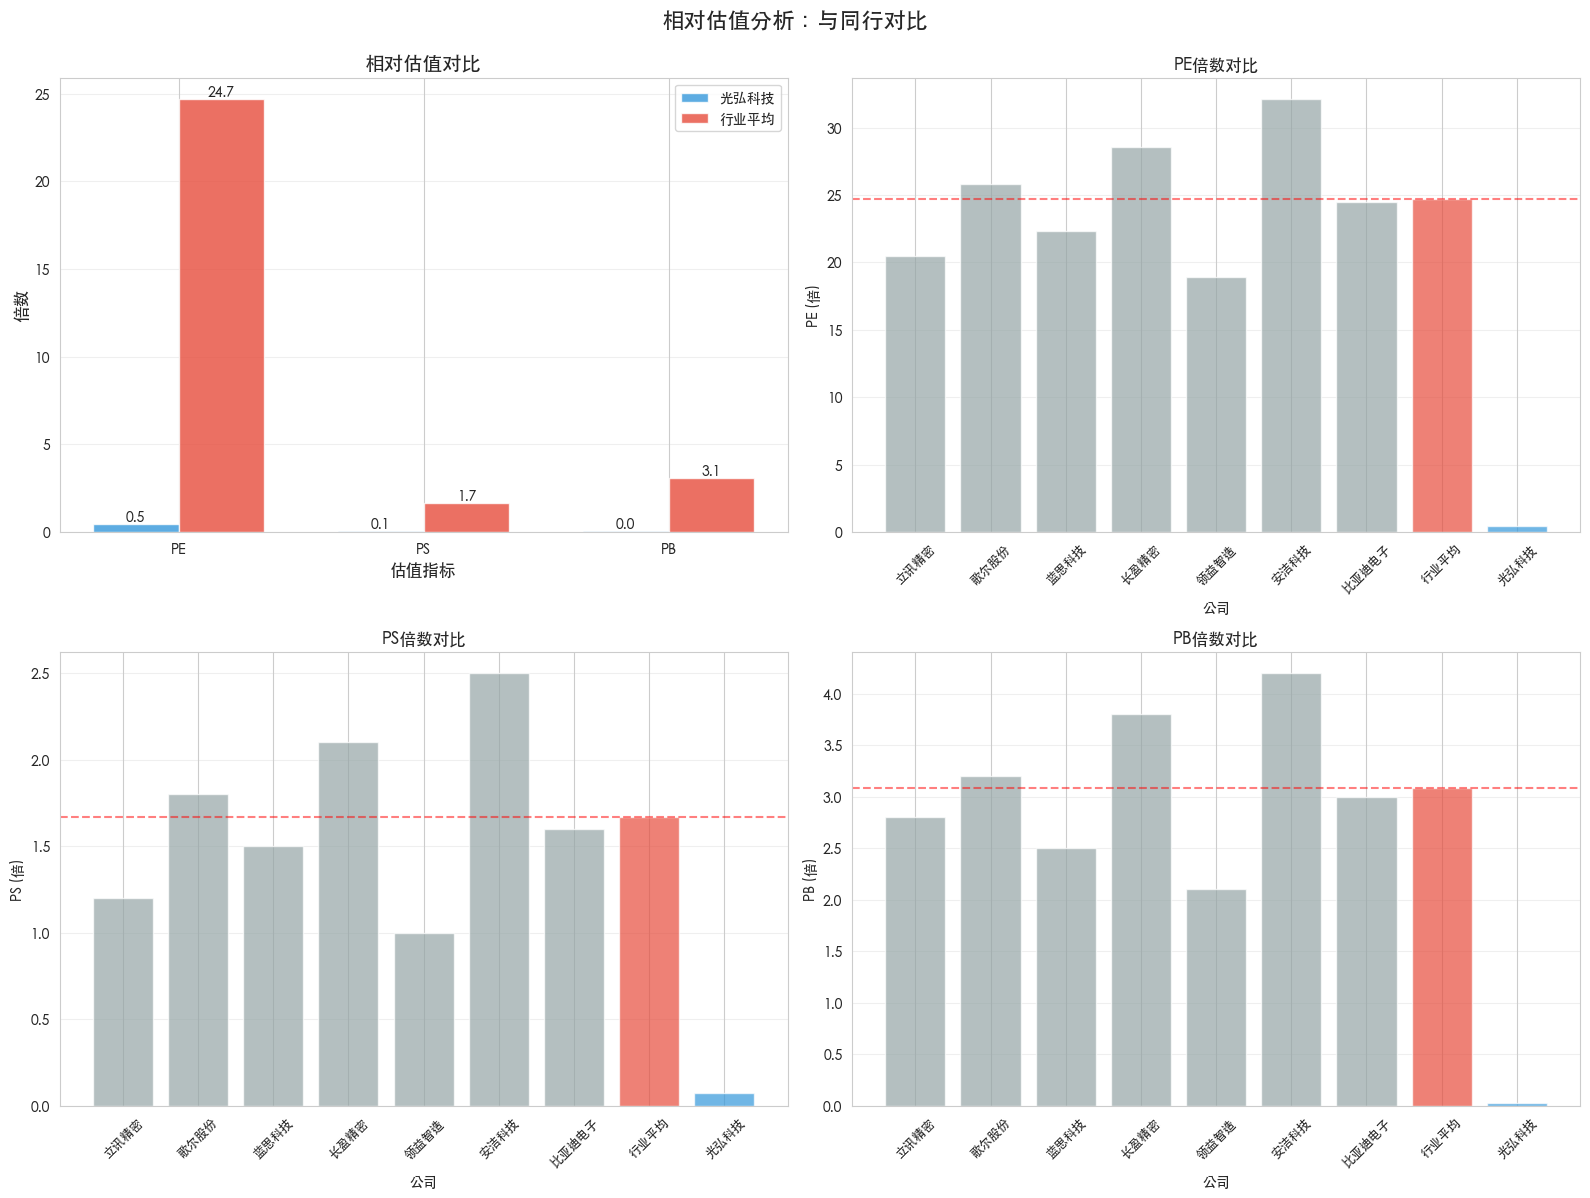

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. 估值指标对比柱状图
ax1 = axes[0, 0]
metrics = ['PE', 'PS', 'PB']
current_vals = [current_metrics['pe'], current_metrics['ps'], current_metrics['pb']]
industry_vals = [industry_avg['pe'], industry_avg['ps'], industry_avg['pb']]

x = np.arange(len(metrics))
width = 0.35

bars1 = ax1.bar(x - width/2, current_vals, width, label='光弘科技', color='#3498db', alpha=0.8)
bars2 = ax1.bar(x + width/2, industry_vals, width, label='行业平均', color='#e74c3c', alpha=0.8)

ax1.set_xlabel('估值指标', fontproperties=font_prop, fontsize=12)
ax1.set_ylabel('倍数', fontproperties=font_prop, fontsize=12)
ax1.set_title('相对估值对比', fontproperties=font_prop, fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics, fontproperties=font_prop)
ax1.legend(prop=font_prop)
ax1.grid(True, alpha=0.3, axis='y')
for label in ax1.get_yticklabels():
    label.set_fontproperties(font_prop)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}', ha='center', va='bottom', fontsize=10, fontproperties=font_prop)

# 2. PE对比
ax2 = axes[0, 1]
peer_names = list(peer_companies_data['name'])
peer_pes = list(peer_companies_data['pe'])
peer_pes.append(industry_avg['pe'])
peer_names.append('行业平均')
peer_pes.append(current_metrics['pe'])
peer_names.append('光弘科技')

colors_pe = ['#95a5a6'] * len(peer_companies_data) + ['#e74c3c', '#3498db']
bars = ax2.bar(range(len(peer_names)), peer_pes, color=colors_pe, alpha=0.7)
ax2.axhline(y=industry_avg['pe'], color='red', linestyle='--', alpha=0.5, label='行业平均')
ax2.set_xlabel('公司', fontproperties=font_prop, fontsize=10)
ax2.set_ylabel('PE (倍)', fontproperties=font_prop, fontsize=10)
ax2.set_title('PE倍数对比', fontproperties=font_prop, fontsize=12, fontweight='bold')
ax2.set_xticks(range(len(peer_names)))
ax2.set_xticklabels(peer_names, fontproperties=font_prop, fontsize=9, rotation=45)
ax2.grid(True, alpha=0.3, axis='y')
for label in ax2.get_yticklabels():
    label.set_fontproperties(font_prop)

# 3. PS对比
ax3 = axes[1, 0]
peer_pss = list(peer_companies_data['ps'])
peer_pss.append(industry_avg['ps'])
peer_pss.append(current_metrics['ps'])

bars = ax3.bar(range(len(peer_names)), peer_pss, color=colors_pe, alpha=0.7)
ax3.axhline(y=industry_avg['ps'], color='red', linestyle='--', alpha=0.5)
ax3.set_xlabel('公司', fontproperties=font_prop, fontsize=10)
ax3.set_ylabel('PS (倍)', fontproperties=font_prop, fontsize=10)
ax3.set_title('PS倍数对比', fontproperties=font_prop, fontsize=12, fontweight='bold')
ax3.set_xticks(range(len(peer_names)))
ax3.set_xticklabels(peer_names, fontproperties=font_prop, fontsize=9, rotation=45)
ax3.grid(True, alpha=0.3, axis='y')
for label in ax3.get_yticklabels():
    label.set_fontproperties(font_prop)

# 4. PB对比
ax4 = axes[1, 1]
peer_pbs = list(peer_companies_data['pb'])
peer_pbs.append(industry_avg['pb'])
peer_pbs.append(current_metrics['pb'])

bars = ax4.bar(range(len(peer_names)), peer_pbs, color=colors_pe, alpha=0.7)
ax4.axhline(y=industry_avg['pb'], color='red', linestyle='--', alpha=0.5)
ax4.set_xlabel('公司', fontproperties=font_prop, fontsize=10)
ax4.set_ylabel('PB (倍)', fontproperties=font_prop, fontsize=10)
ax4.set_title('PB倍数对比', fontproperties=font_prop, fontsize=12, fontweight='bold')
ax4.set_xticks(range(len(peer_names)))
ax4.set_xticklabels(peer_names, fontproperties=font_prop, fontsize=9, rotation=45)
ax4.grid(True, alpha=0.3, axis='y')
for label in ax4.get_yticklabels():
    label.set_fontproperties(font_prop)

plt.suptitle('相对估值分析：与同行对比', fontproperties=font_prop, fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

## 7. 估值回归情景分析

In [8]:
# 分析：如果估值回归到行业平均水平，股价会如何变化？

print('\n=== 估值回归情景分析 ===')
print('\n情景1: 估值回归到行业平均水平')
print('-' * 50)

# 基于行业平均PE的目标价格
eps = net_income / total_shares  # 每股收益
target_price_pe = eps * industry_avg['pe']
return_pe = (target_price_pe - current_price) / current_price * 100

print(f"当前EPS: {eps:.2f} 元/股")
print(f"当前PE: {current_metrics['pe']:.2f} 倍")
print(f"行业平均PE: {industry_avg['pe']:.2f} 倍")
print(f"\n如果PE回归到行业平均:")
print(f"  目标价格 = EPS × 行业平均PE")
print(f"  目标价格 = {eps:.2f} × {industry_avg['pe']:.2f} = {target_price_pe:.2f} 元")
print(f"  预期收益率: {return_pe:+.1f}%")

# 基于行业平均PB的目标价格
bps = net_assets / total_shares  # 每股净资产
target_price_pb = bps * industry_avg['pb']
return_pb = (target_price_pb - current_price) / current_price * 100

print(f"\n当前BPS: {bps:.2f} 元/股")
print(f"当前PB: {current_metrics['pb']:.2f} 倍")
print(f"行业平均PB: {industry_avg['pb']:.2f} 倍")
print(f"\n如果PB回归到行业平均:")
print(f"  目标价格 = BPS × 行业平均PB")
print(f"  目标价格 = {bps:.2f} × {industry_avg['pb']:.2f} = {target_price_pb:.2f} 元")
print(f"  预期收益率: {return_pb:+.1f}%")

# 综合估值（PE和PB的平均）
target_price_avg = (target_price_pe + target_price_pb) / 2
return_avg = (target_price_avg - current_price) / current_price * 100

print(f"\n综合估值目标价格: {target_price_avg:.2f} 元")
print(f"预期收益率: {return_avg:+.1f}%")


=== 估值回归情景分析 ===

情景1: 估值回归到行业平均水平
--------------------------------------------------
当前EPS: 50.71 元/股
当前PE: 0.47 倍
行业平均PE: 24.67 倍

如果PE回归到行业平均:
  目标价格 = EPS × 行业平均PE
  目标价格 = 50.71 × 24.67 = 1251.00 元
  预期收益率: +5138.7%

当前BPS: 987.93 元/股
当前PB: 0.02 倍
行业平均PB: 3.09 倍

如果PB回归到行业平均:
  目标价格 = BPS × 行业平均PB
  目标价格 = 987.93 × 3.09 = 3048.46 元
  预期收益率: +12665.8%

综合估值目标价格: 2149.73 元
预期收益率: +8902.2%


## 8. 估值情景总结


=== 估值情景对比表 ===
     情景        PE       PB       PS     目标价格(元)     预期收益率(%)
   当前估值  0.470946 0.024172 0.070642   23.880000     0.000000
PE→行业平均 24.671429 0.024172 0.070642 1251.000953  5138.697459
PB→行业平均  0.470946 3.085714 0.070642 3048.462945 12665.757726
   全面回归 24.671429 3.085714 1.671429 2149.731949  8902.227593
 行业最低估值 18.900000 2.100000 1.671429 1516.500300  6250.503769
 行业最高估值 32.100000 4.200000 1.671429 2888.487172 11995.842429


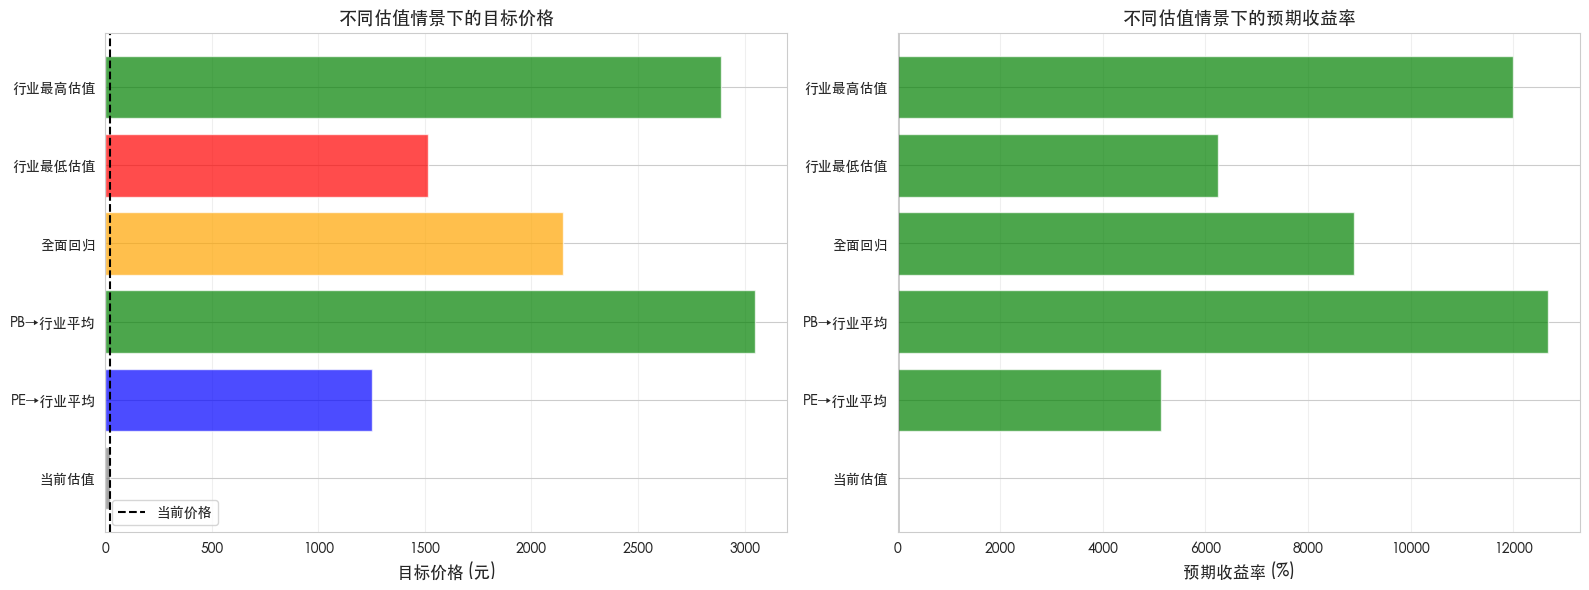

In [9]:
# 创建情景对比表
scenarios_data = []

# 情景1: 当前估值
scenarios_data.append(['当前估值', current_metrics['pe'], current_metrics['pb'], current_metrics['ps'], current_price, 0])

# 情景2: PE回归到行业平均
scenarios_data.append(['PE→行业平均', industry_avg['pe'], current_metrics['pb'], current_metrics['ps'], target_price_pe, return_pe])

# 情景3: PB回归到行业平均
scenarios_data.append(['PB→行业平均', current_metrics['pe'], industry_avg['pb'], current_metrics['ps'], target_price_pb, return_pb])

# 情景4: 全面回归行业平均
scenarios_data.append(['全面回归', industry_avg['pe'], industry_avg['pb'], industry_avg['ps'], target_price_avg, return_avg])

# 情景5: 行业最低估值（悲观）
min_pe = peer_companies_data['pe'].min()
min_pb = peer_companies_data['pb'].min()
target_price_pessimistic = (eps * min_pe + bps * min_pb) / 2
return_pessimistic = (target_price_pessimistic - current_price) / current_price * 100
scenarios_data.append(['行业最低估值', min_pe, min_pb, industry_avg['ps'], target_price_pessimistic, return_pessimistic])

# 情景6: 行业最高估值（乐观）
max_pe = peer_companies_data['pe'].max()
max_pb = peer_companies_data['pb'].max()
target_price_optimistic = (eps * max_pe + bps * max_pb) / 2
return_optimistic = (target_price_optimistic - current_price) / current_price * 100
scenarios_data.append(['行业最高估值', max_pe, max_pb, industry_avg['ps'], target_price_optimistic, return_optimistic])

df_scenarios = pd.DataFrame(scenarios_data, columns=['情景', 'PE', 'PB', 'PS', '目标价格(元)', '预期收益率(%)'])

print('\n=== 估值情景对比表 ===')
print(df_scenarios.to_string(index=False))

# 可视化情景分析
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 左图：目标价格对比
colors_scenario = ['gray', 'blue', 'green', 'orange', 'red', 'green']
bars1 = ax1.barh(df_scenarios['情景'], df_scenarios['目标价格(元)'], color=colors_scenario, alpha=0.7)
ax1.axvline(x=current_price, color='black', linestyle='--', label='当前价格')
ax1.set_xlabel('目标价格 (元)', fontproperties=font_prop, fontsize=12)
ax1.set_title('不同估值情景下的目标价格', fontproperties=font_prop, fontsize=13, fontweight='bold')
ax1.legend(prop=font_prop)
for label in ax1.get_xticklabels():
    label.set_fontproperties(font_prop)
for label in ax1.get_yticklabels():
    label.set_fontproperties(font_prop)
ax1.grid(True, alpha=0.3, axis='x')

# 右图：预期收益率对比
colors_return = ['green' if r > 0 else 'red' for r in df_scenarios['预期收益率(%)']]
bars2 = ax2.barh(df_scenarios['情景'], df_scenarios['预期收益率(%)'], color=colors_return, alpha=0.7)
ax2.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax2.set_xlabel('预期收益率 (%)', fontproperties=font_prop, fontsize=12)
ax2.set_title('不同估值情景下的预期收益率', fontproperties=font_prop, fontsize=13, fontweight='bold')
for label in ax2.get_xticklabels():
    label.set_fontproperties(font_prop)
for label in ax2.get_yticklabels():
    label.set_fontproperties(font_prop)
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## 9. 相对估值结论

In [10]:
print('\n' + '='*60)
print('相对估值分析结论')
print('='*60)

print(f"\n1. 当前估值水平:")
if current_metrics['pe'] < industry_avg['pe']:
    print(f"   PE ({current_metrics['pe']:.1f}倍) 低于行业平均 ({industry_avg['pe']:.1f}倍)")
    print(f"   → 股价可能被低估")
else:
    print(f"   PE ({current_metrics['pe']:.1f}倍) 高于行业平均 ({industry_avg['pe']:.1f}倍)")
    print(f"   → 股价可能被高估")

print(f"\n2. 估值回归空间:")
print(f"   如果估值回归到行业平均，预期收益率: {return_avg:+.1f}%")

if abs(return_avg) < 10:
    risk_level = "低风险 - 估值接近行业均值"
elif abs(return_avg) < 30:
    risk_level = "中等风险 - 估值有一定偏离"
else:
    risk_level = "高风险 - 估值偏离较大"

print(f"\n3. 投资建议:")
print(f"   {risk_level}")

if return_avg > 10:
    print(f"   建议: 估值偏低，具有投资价值")
elif return_avg < -10:
    print(f"   建议: 估值偏高，需谨慎投资")
else:
    print(f"   建议: 估值合理，可正常投资")

print(f"\n4. 敏感性分析:")
print(f"   - 悡价每变动1元，对应收益率变动: {100/current_price:.1f}%")
print(f"   - PE每变动1倍，对应目标价格变动: {eps:.2f} 元")


相对估值分析结论

1. 当前估值水平:
   PE (0.5倍) 低于行业平均 (24.7倍)
   → 股价可能被低估

2. 估值回归空间:
   如果估值回归到行业平均，预期收益率: +8902.2%

3. 投资建议:
   高风险 - 估值偏离较大
   建议: 估值偏低，具有投资价值

4. 敏感性分析:
   - 悡价每变动1元，对应收益率变动: 4.2%
   - PE每变动1倍，对应目标价格变动: 50.71 元
